# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [3]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [4]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [5]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [6]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [7]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun

In [8]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [9]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [10]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


## Display an event

In [11]:
dataevts = data.groupby('dataset_id')

In [21]:
evt         = dataevts.get_group(22)
bin_widths  = evtfun.get_bin_widths(bin_info)


In [23]:
coors = evtfun.get_coors(evt, bin_info)
bins  = evtfun.get_bins(coors, bin_widths)
ene   = 1e3* evt.energy.values 

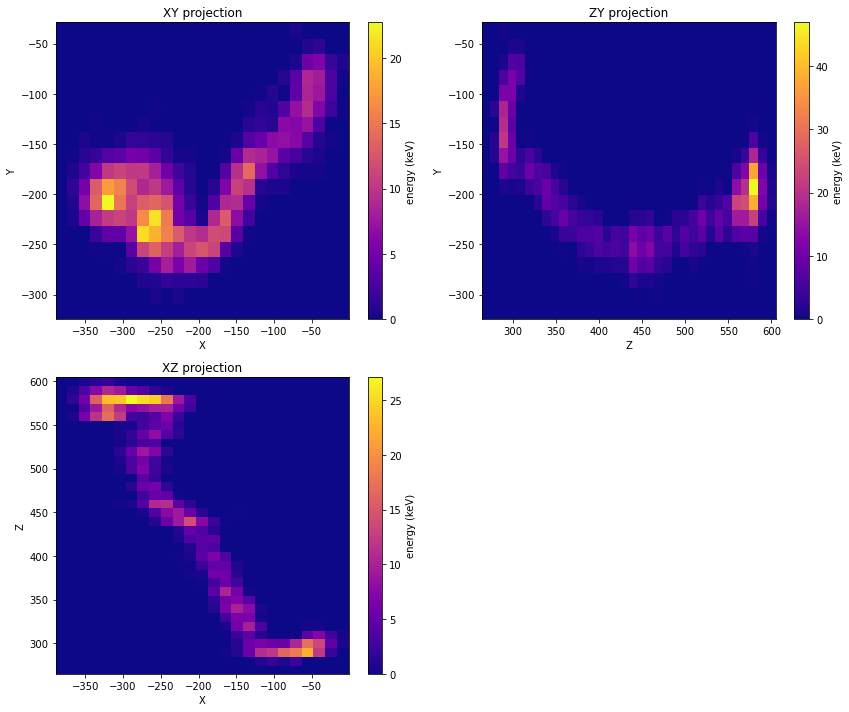

In [24]:
evtfun.event_display(coors, bins, ene = ene);

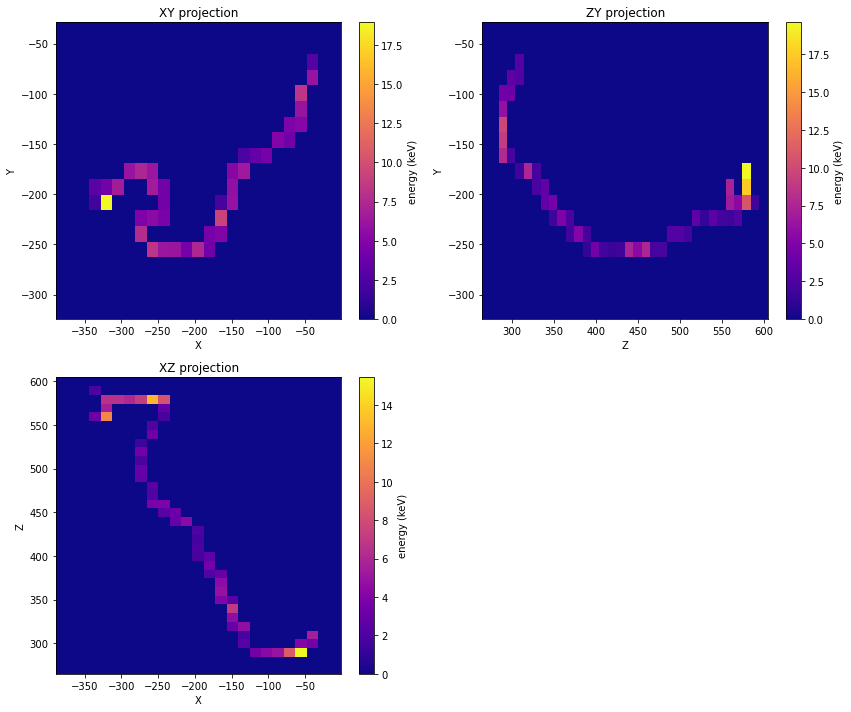

In [27]:
evtdeco   = evt[evt.decopred == 1]
enedeco   = 1e3* evtdeco.energy.values 
coorsdeco = evtfun.get_coors(evtdeco, bin_info)
evtfun.event_display(coorsdeco, bins = bins, ene = enedeco);


## Display graph

In [28]:
graph                      = graphfun.convert_to_graph(coorsdeco, bins, enedeco, nsides = 3)
componentes, longest_graph = graphfun.graph_connectivity(graph)
_, longest_graph2          = graphfun.graph_connectivity(longest_graph)

[(-1, -1, -1), (-1, -1, 0), (-1, -1, 1), (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), (-1, 1, -1), (-1, 1, 0), (-1, 1, 1), (0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (0, 0, 0), (0, 0, 1), (0, 1, -1), (0, 1, 0), (0, 1, 1), (1, -1, -1), (1, -1, 0), (1, -1, 1), (1, 0, -1), (1, 0, 0), (1, 0, 1), (1, 1, -1), (1, 1, 0), (1, 1, 1)]
Is graph conected?  True
Number of components: 1
Component 1: {(10, 4, 17), (13, 4, 13), (9, 8, 31), (9, 4, 19), (16, 9, 4), (19, 11, 2), (21, 13, 2), (8, 9, 31), (22, 15, 3), (16, 9, 5), (14, 7, 8), (10, 4, 18), (21, 12, 2), (16, 10, 3), (3, 8, 29), (7, 9, 31), (15, 9, 6), (13, 5, 11), (8, 6, 28), (7, 6, 26), (8, 4, 19), (15, 9, 5), (17, 10, 2), (15, 8, 6), (5, 8, 31), (7, 5, 24), (4, 8, 29), (15, 7, 7), (22, 16, 4), (15, 8, 7), (3, 7, 32), (4, 7, 30), (7, 6, 25), (9, 7, 31), (13, 5, 12), (14, 5, 10), (18, 10, 2), (6, 9, 31), (4, 7, 31), (14, 5, 11), (9, 6, 29), (7, 5, 23), (14, 6, 10), (8, 6, 27), (15, 7, 8), (20, 12, 2), (22, 15, 4), (9, 6, 30), (7, 5, 22), (12, 4

extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 8, 29)
extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 7, 32)


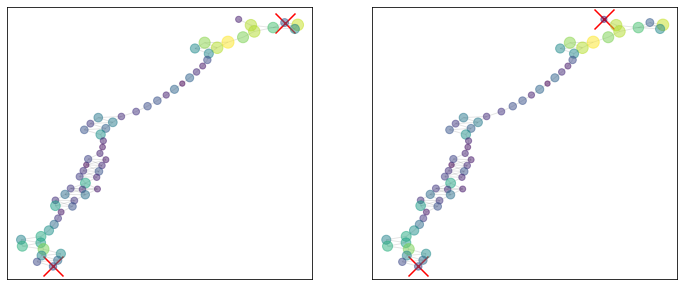

In [35]:
cv = pltext.canvas(2, 2)
cv(1)
u, v, dist = graphfun.graph_extremes(graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(graph, (u, v))
cv(2)
u, v, dist = graphfun.graph_extremes(longest_graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(longest_graph, (u, v))